In [1]:
import cogsworth
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
reload(constants)
files = ["fiducial", "fryer_rapid", "mandel_muller", 'maltsev_fallback_0.0', 'maltsev_fallback_0.25',
         'maltsev_fallback_0.5', 'maltsev_fallback_0.75', 'maltsev_fallback_1.0',
         'maltsev_pf_prob_0.0', 'maltsev_pf_prob_1.0']
labels = ["Fryer+12 (Delayed)", "Fryer+12 (Rapid)", "Mandel & Muller 2020", r"Maltsev+25 ($f_{\rm fb}=0.0$)",
          r"Maltsev+25 ($f_{\rm fb}=0.25$)", r"Maltsev+25 ($f_{\rm fb}=0.5$)", r"Maltsev+25 ($f_{\rm fb}=0.75$)",
          r"Maltsev+25 ($f_{\rm fb}=1.0$)", r"Maltsev+25 ($P({\rm pf})=0.0$)", r"Maltsev+25 ($P({\rm pf})=1.0$)"]    
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [4]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(
    files=files, labels=labels, colours=colours
)

Loading post-processed data for Fryer+12 (Delayed) from fiducial
Loading post-processed data for Fryer+12 (Rapid) from fryer_rapid
Loading post-processed data for Mandel & Muller 2020 from mandel_muller
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.0$) from maltsev_fallback_0.0
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.25$) from maltsev_fallback_0.25
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.5$) from maltsev_fallback_0.5
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.75$) from maltsev_fallback_0.75
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=1.0$) from maltsev_fallback_1.0
Loading post-processed data for Maltsev+25 ($P({\rm pf})=0.0$) from maltsev_pf_prob_0.0
Loading post-processed data for Maltsev+25 ($P({\rm pf})=1.0$) from maltsev_pf_prob_1.0


In [5]:
def plot_mass_directions(pop, data, co_type="BH", bins=np.linspace(3, 30, 50), fig=None, ax=None, show=True,
                         mc_deg_sep=20, bulge_z_sep=0.5, bulge_r_sep=8.2,
                         **kwargs):
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    if fig is None or ax is None:
        fig, ax = plt.subplots()
    
    # MW microlensing mask
    near_plane = abs(data[pop.label]["pos"]["BH"][:, 2]) < bulge_z_sep
    between_sun_center = np.linalg.norm(data[pop.label]["pos"]["BH"][:, :2], axis=1) < bulge_r_sep
    mw_bulge_mask = near_plane & between_sun_center

    coords = SkyCoord(
        x=data[pop.label]["pos"][co_type][:, 0] * u.kpc,
        y=data[pop.label]["pos"][co_type][:, 1] * u.kpc,
        z=data[pop.label]["pos"][co_type][:, 2] * u.kpc,
        frame="galactocentric",
    ).icrs

    # mask on those that are in the direction magellanic clouds
    lmc = SkyCoord(ra=80.89416667*u.deg, dec=-69.75611111*u.deg)
    smc = SkyCoord(ra=13.15833333*u.deg, dec=-72.80027778*u.deg)
    sep_lmc = coords.separation(lmc)
    sep_smc = coords.separation(smc)
    close_to_lmc = (sep_lmc < mc_deg_sep*u.deg) & (coords.distance < 50*u.kpc)
    close_to_smc = (sep_smc < mc_deg_sep*u.deg) & (coords.distance < 70*u.kpc)

    mc_mask = close_to_lmc | close_to_smc

    # define a mask that's a cone going straight up/down from the sun
    # CONE_DEGS = 15
    # sun_direction = SkyCoord(ra=0*u.deg, dec=90*u.deg)
    # sep_sun = coords.separation(sun_direction)
    # cone_mask = (sep_sun < CONE_DEGS*u.deg)
    # sun_direction = SkyCoord(ra=0*u.deg, dec=-90*u.deg)
    # sep_sun = coords.separation(sun_direction)
    # cone_mask |= (sep_sun < CONE_DEGS*u.deg)

    for mask, label, c in zip([mw_bulge_mask, mc_mask], ["Towards MW bulge", "Towards MC Clouds"], ["tab:blue", "tab:orange"]):
        print(mask.sum())
        plotting.nice_transparent_hist(
            ax=ax, data=data[pop.label]["mass"][co_type][mask],
            colour=c,
            bins=bins, density=True, label=label, alpha=0.5, lw=2
        )

    ax.legend()

    ax.set(
        xlabel=kwargs.pop("xlabel", f"Mass of {co_type} [M$_\odot$]"),
        ylabel=kwargs.pop("ylabel", "Density"),
        **kwargs
    )

    if show:
        plt.show()
    return fig, ax

100327
1511
94436
594
190857
316
25493
132


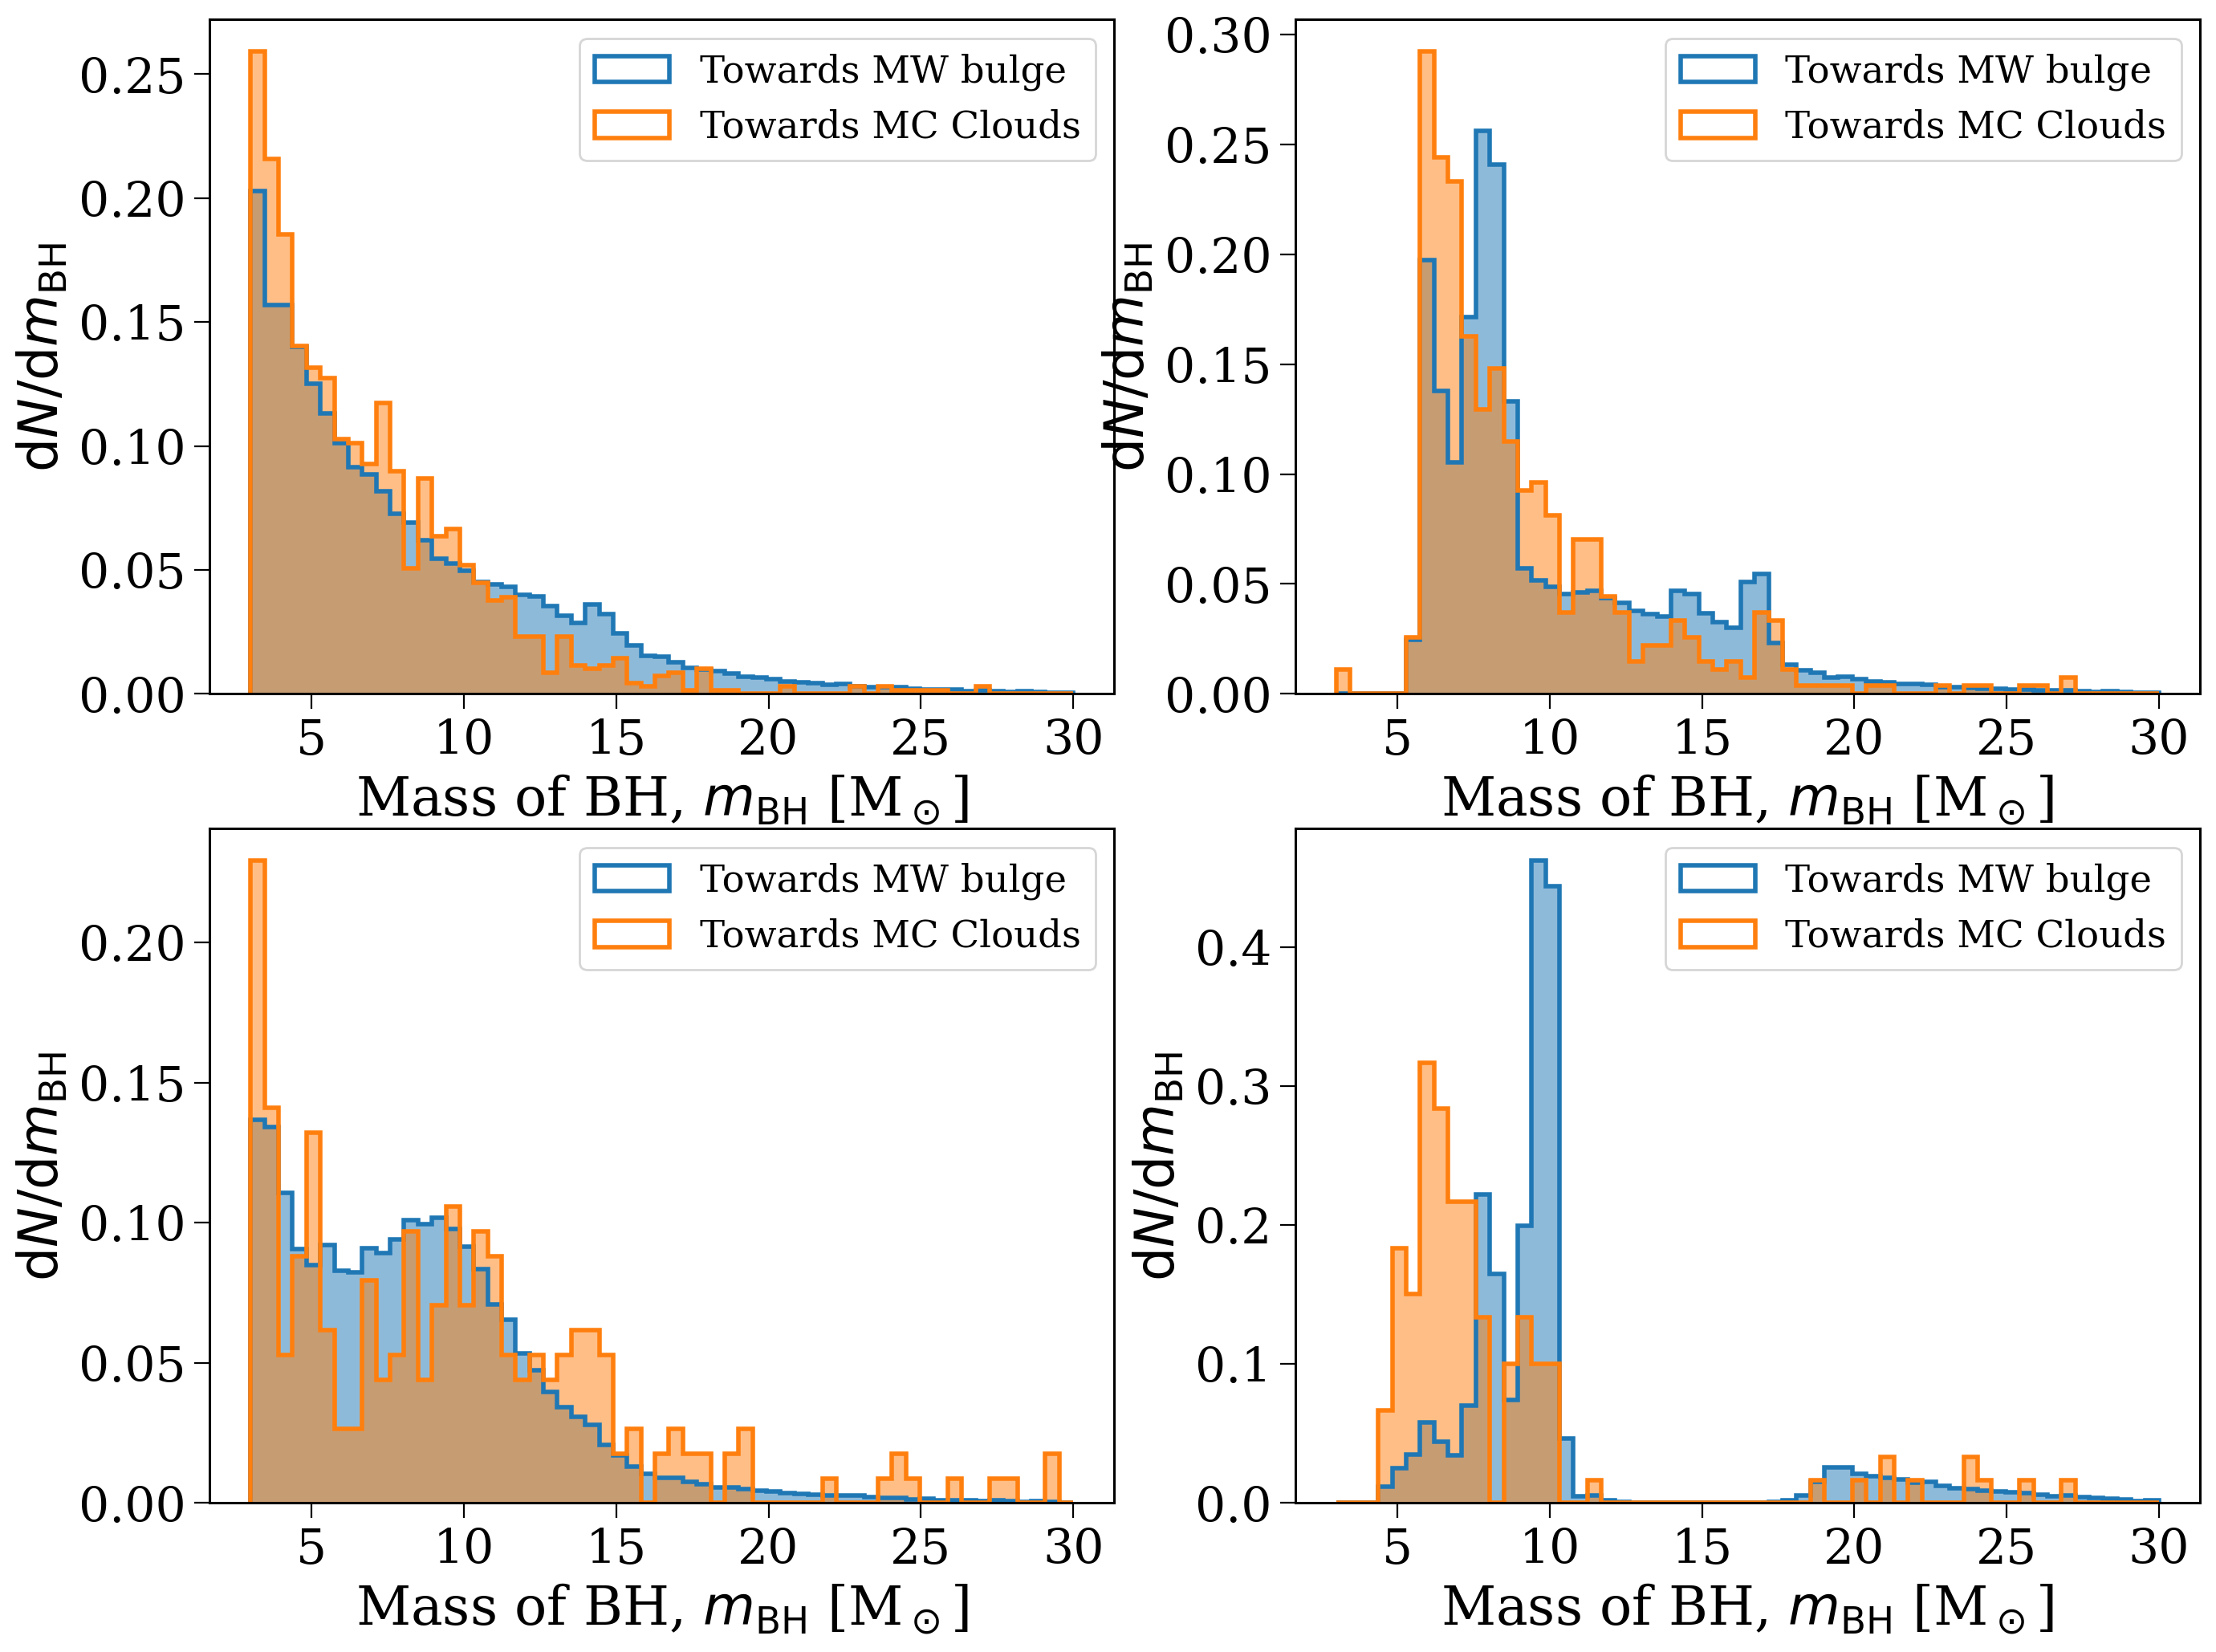

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax_list = axes.flatten()
i = 0

for pop in pops:
    if pop.label.startswith("Maltsev") and "0.5" not in pop.label:
        continue
    ax = ax_list[i]
    plot_mass_directions(pop, data, bins=np.linspace(3, 30, 60),
                         xlabel=r"Mass of BH, $m_{\rm BH}$ [M$_\odot$]",
                         ylabel=r"${\rm d}N/{\rm d}m_{\rm BH}$",
                         ax=ax, fig=fig, show=False)
    
    i += 1
plt.show()

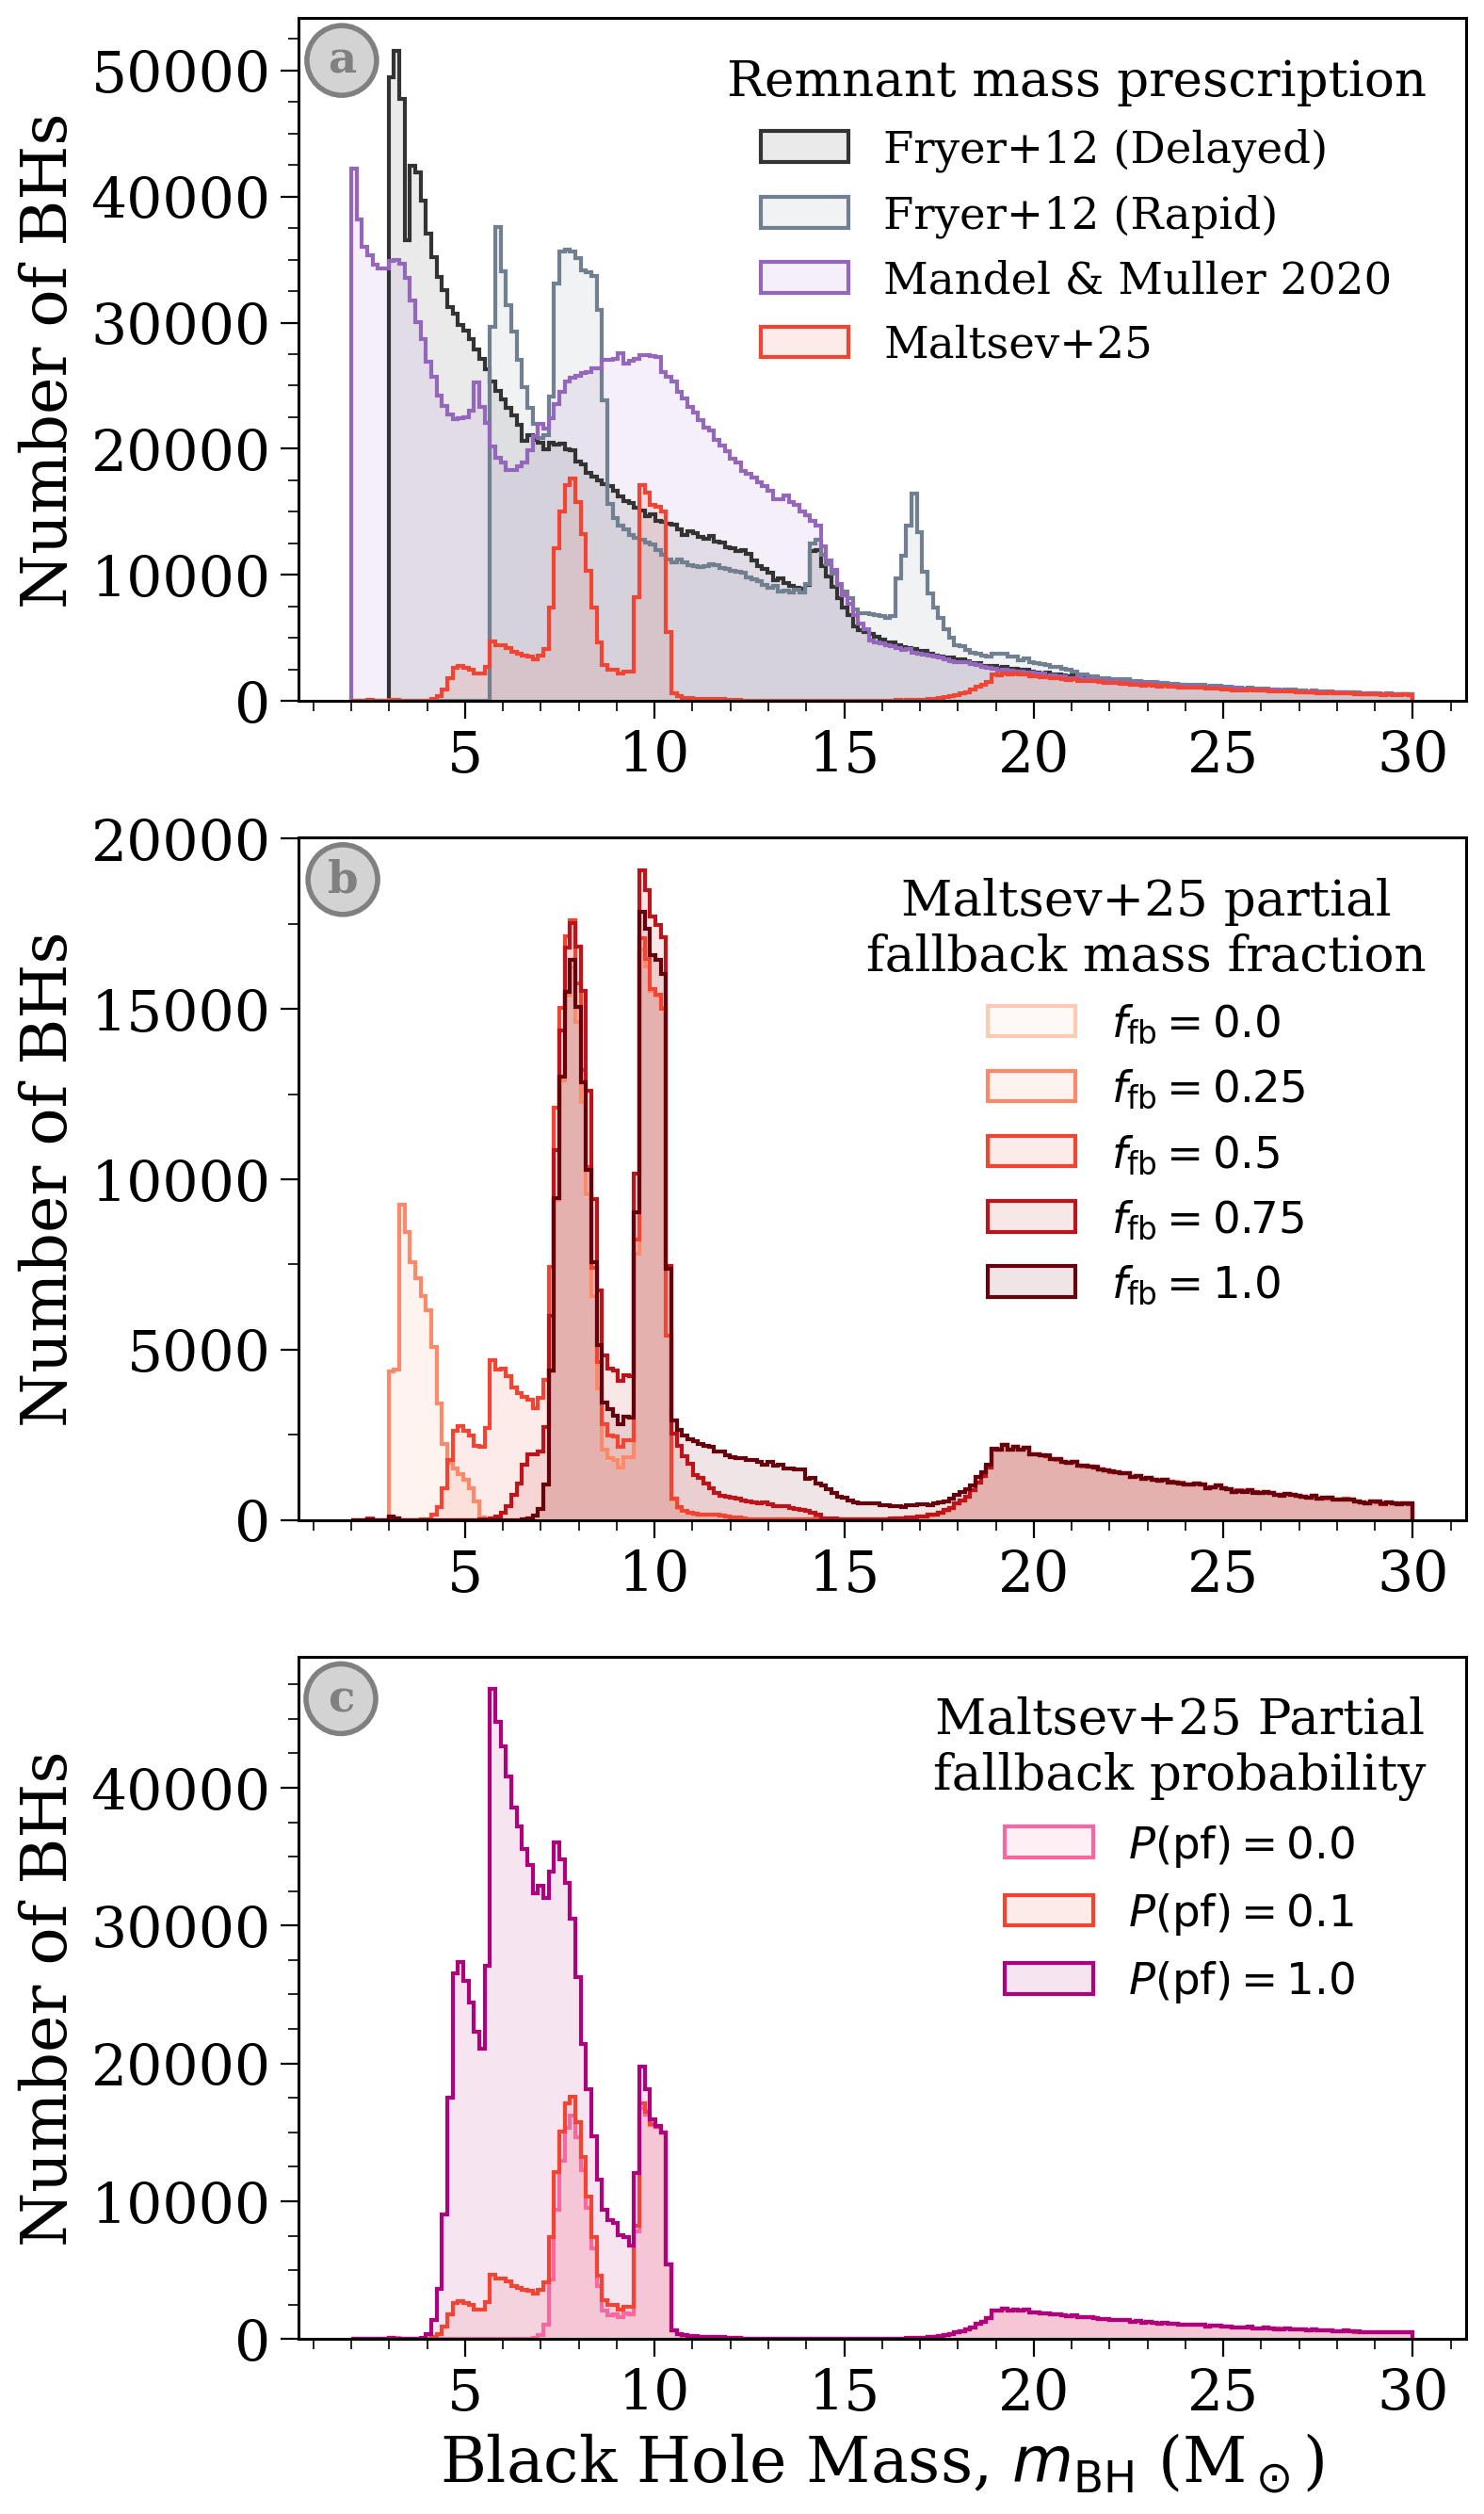

In [ ]:
reload(plotting)

fig, axes = plt.subplots(3, 1, figsize=(8, 16))

BINS = np.linspace(2, 30, 200)
LW = 1.5

plotting.plot_mass_histogram(
    pops=[p for p in pops if ("Maltsev" not in p.label or "fb}=0.5" in p.label)],
    labels=["Fryer+12 (Delayed)", "Fryer+12 (Rapid)", "Mandel & Muller 2020", "Maltsev+25"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    legend_title="Remnant mass prescription",
    density=False,
    fig=fig,
    ax=axes[0],
    show=False,
    lw=LW
)

plotting.plot_mass_histogram(
    pops=[p for p in pops if "fb" in p.label],
    labels=[rf"$f_{{\rm fb}}={f}$" for f in [0.0, 0.25, 0.5, 0.75, 1.0]],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    density=False,
    legend_title="Maltsev+25 partial\nfallback mass fraction",
    fig=fig,
    ax=axes[1],
    show=False,
    lw=LW
)

plotting.plot_mass_histogram(
    pops=[pops[-2], pops[5], pops[-1]],
    labels=[r"$P({\rm pf})=0.0$", r"$P({\rm pf})=0.1$", r"$P({\rm pf})=1.0$"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"Number of BHs",
    density=False,
    alpha=0.1,
    legend_title="Maltsev+25 Partial\nfallback probability",
    fig=fig,
    ax=axes[2],
    show=False,
    lw=LW
)

for let, ax in zip(["a", "b", "c"], axes):
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(2500))

    ax.annotate(f"{let}", xy=(0.025, 0.97), xycoords='axes fraction', fontsize=0.7*fs, bbox=dict(boxstyle="circle", fc="lightgrey", ec="grey", lw=2), ha='left', va='top', color='grey', fontweight='bold')

# plt.savefig("../plots/bh_mass_rm_variations.pdf", format="pdf", bbox_inches='tight')
plt.show()

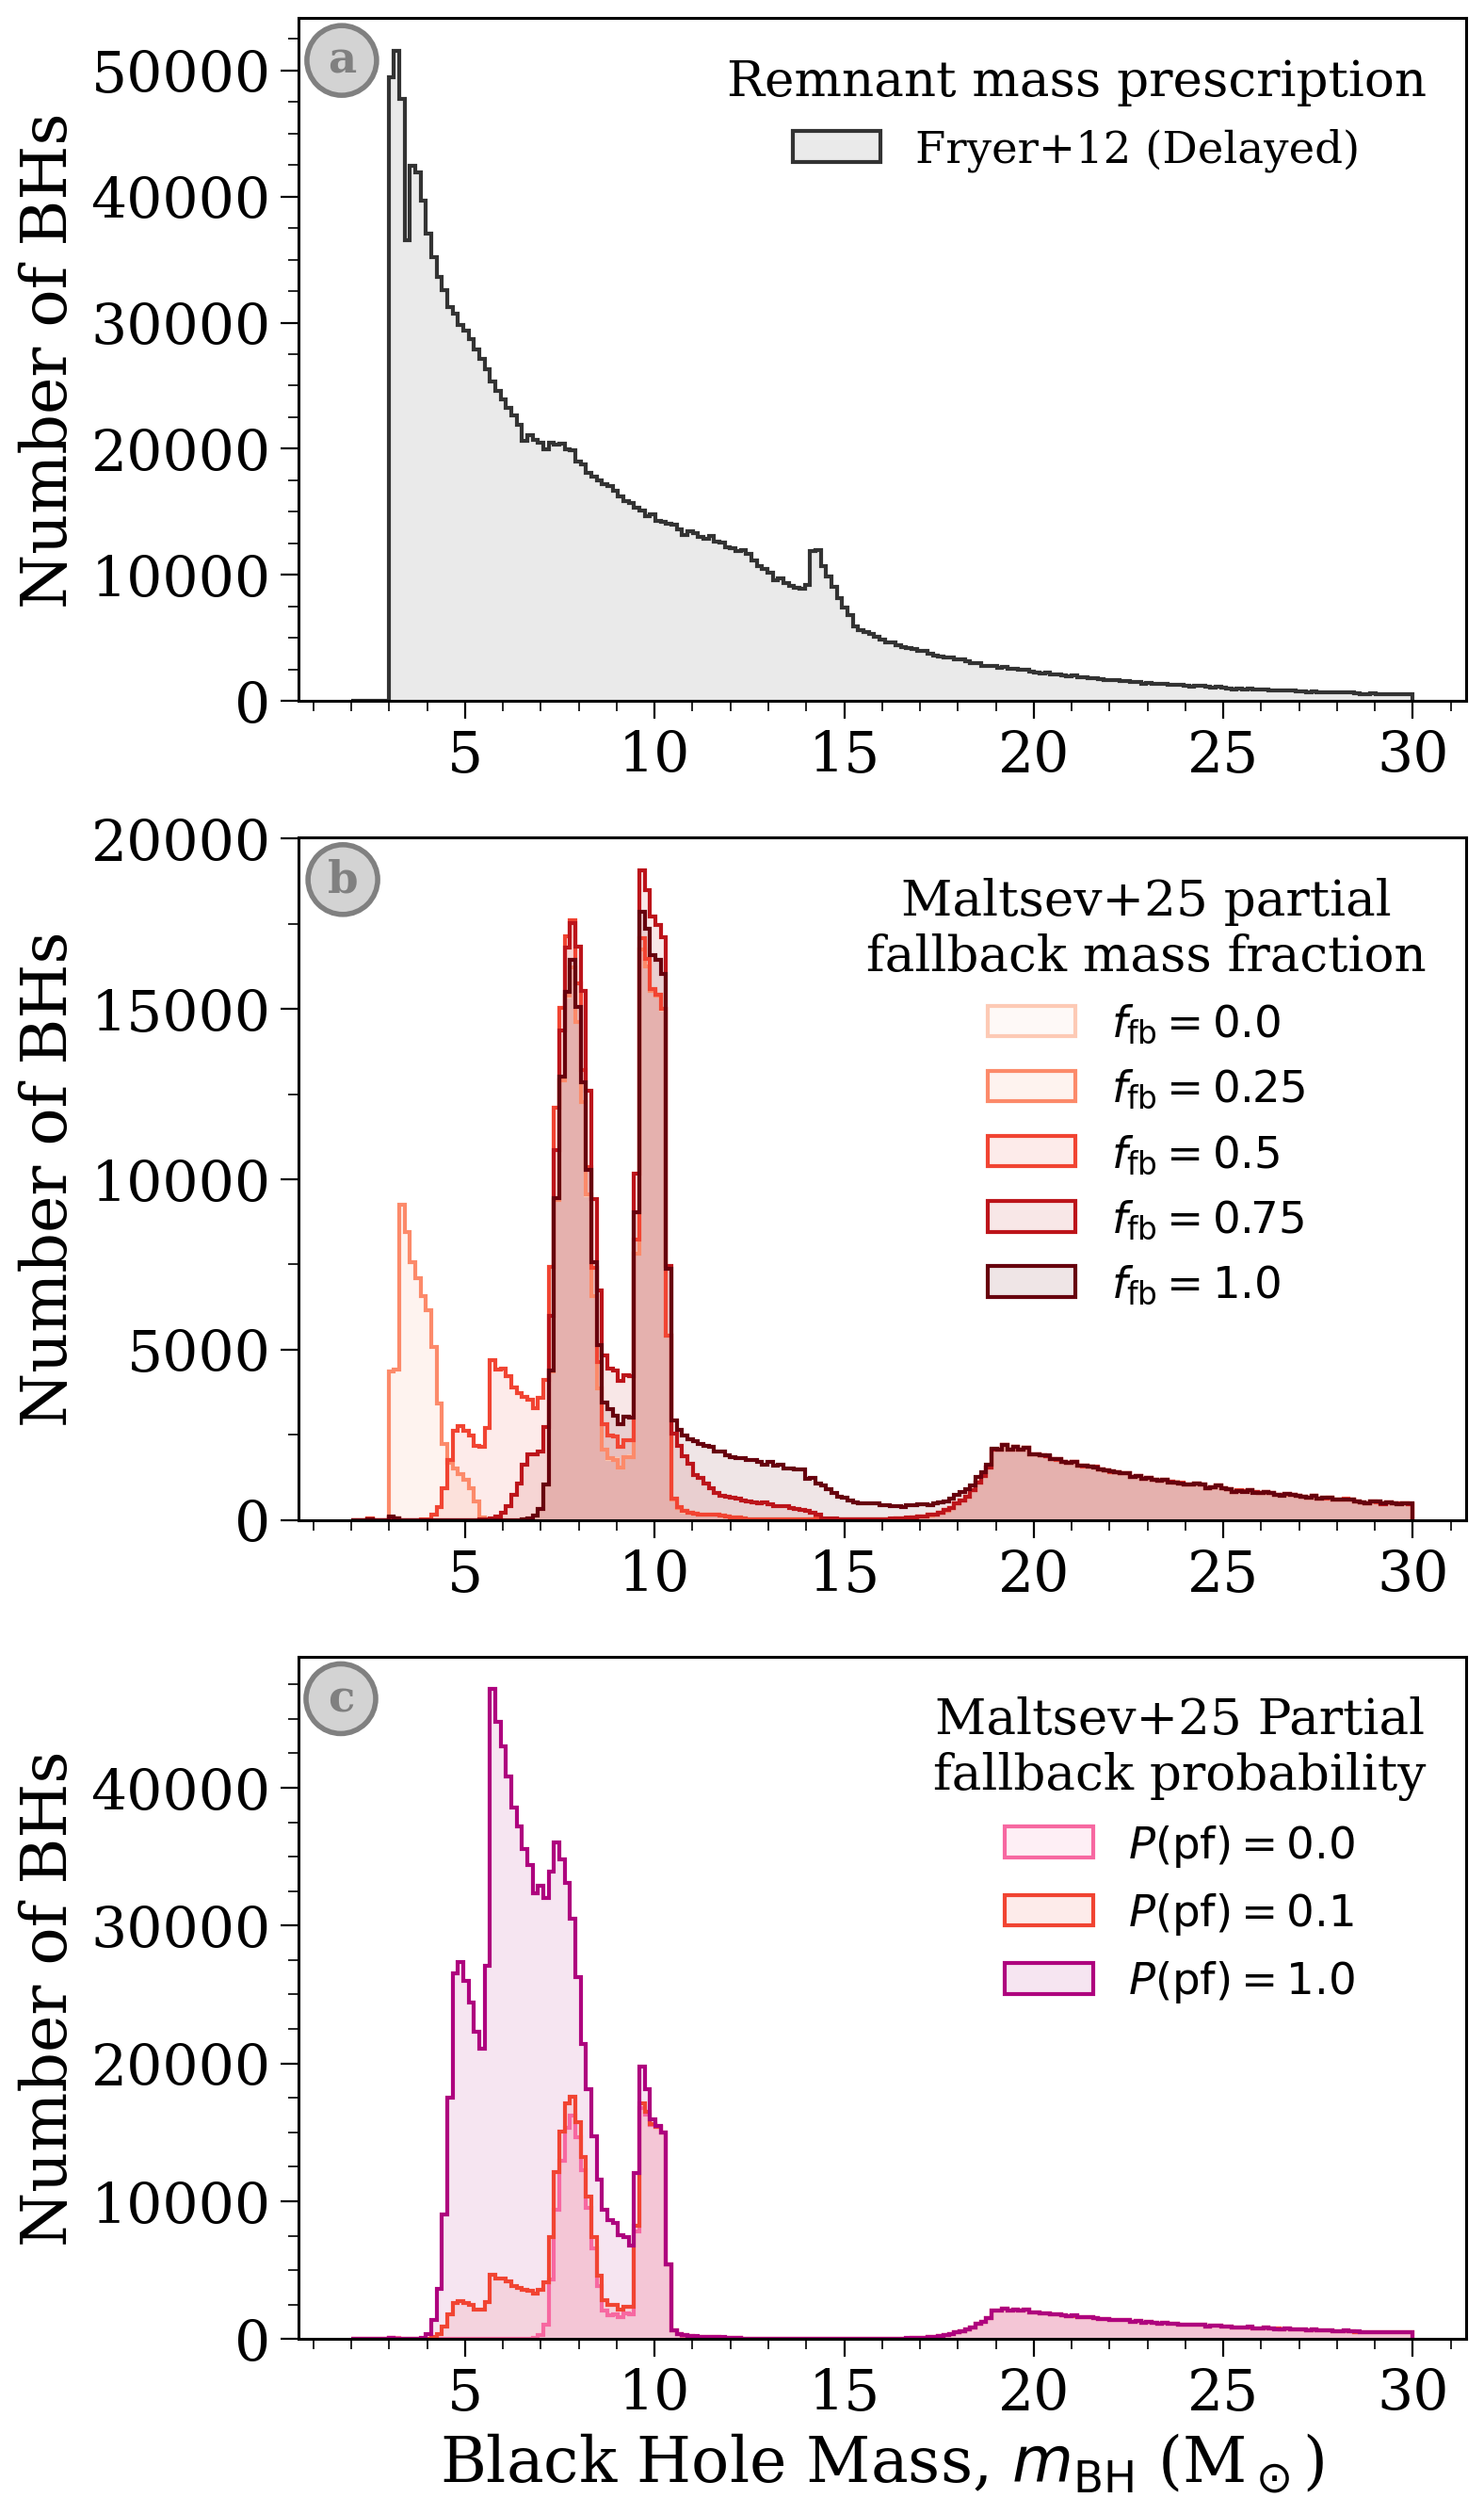

In [8]:
reload(plotting)

fig, axes = plt.subplots(3, 1, figsize=(8, 16))

BINS = np.linspace(2, 30, 200)
LW = 1.5

plotting.plot_mass_histogram(
    pops=[pops[0]],
    labels=["Fryer+12 (Delayed)"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    legend_title="Remnant mass prescription",
    density=False,
    fig=fig,
    ax=axes[0],
    show=False,
    lw=LW
)

plotting.plot_mass_histogram(
    pops=[p for p in pops if "fb" in p.label],
    labels=[rf"$f_{{\rm fb}}={f}$" for f in [0.0, 0.25, 0.5, 0.75, 1.0]],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    density=False,
    legend_title="Maltsev+25 partial\nfallback mass fraction",
    fig=fig,
    ax=axes[1],
    show=False,
    lw=LW
)

plotting.plot_mass_histogram(
    pops=[pops[-2], pops[5], pops[-1]],
    labels=[r"$P({\rm pf})=0.0$", r"$P({\rm pf})=0.1$", r"$P({\rm pf})=1.0$"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"Number of BHs",
    density=False,
    alpha=0.1,
    legend_title="Maltsev+25 Partial\nfallback probability",
    fig=fig,
    ax=axes[2],
    show=False,
    lw=LW
)

for let, ax in zip(["a", "b", "c"], axes):
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(2500))

    ax.annotate(f"{let}", xy=(0.025, 0.97), xycoords='axes fraction', fontsize=0.7*fs, bbox=dict(boxstyle="circle", fc="lightgrey", ec="grey", lw=2), ha='left', va='top', color='grey', fontweight='bold')

plt.savefig("../plots/bh_mass_rm_variations_just_fid.pdf", format="pdf", bbox_inches='tight')
plt.show()

[ 0.92910161  0.65945383  2.30800898 13.71713754]
[ 10.55050975  12.92260994  42.71168467 719.18949711]
[ 0.95497711  0.67193513  3.0602458  19.35393887]
[  9.2578635   10.52371567  45.05919157 889.1280173 ]
[ 0.98956842  0.63563505  3.91161334 29.17363834]
[  7.80494276   7.49261477  43.4078058  953.90434814]
[ 0.99218276  0.65733535  3.46226884 27.73659953]
[   9.1136956     8.45962571   40.94688712 1109.49150918]


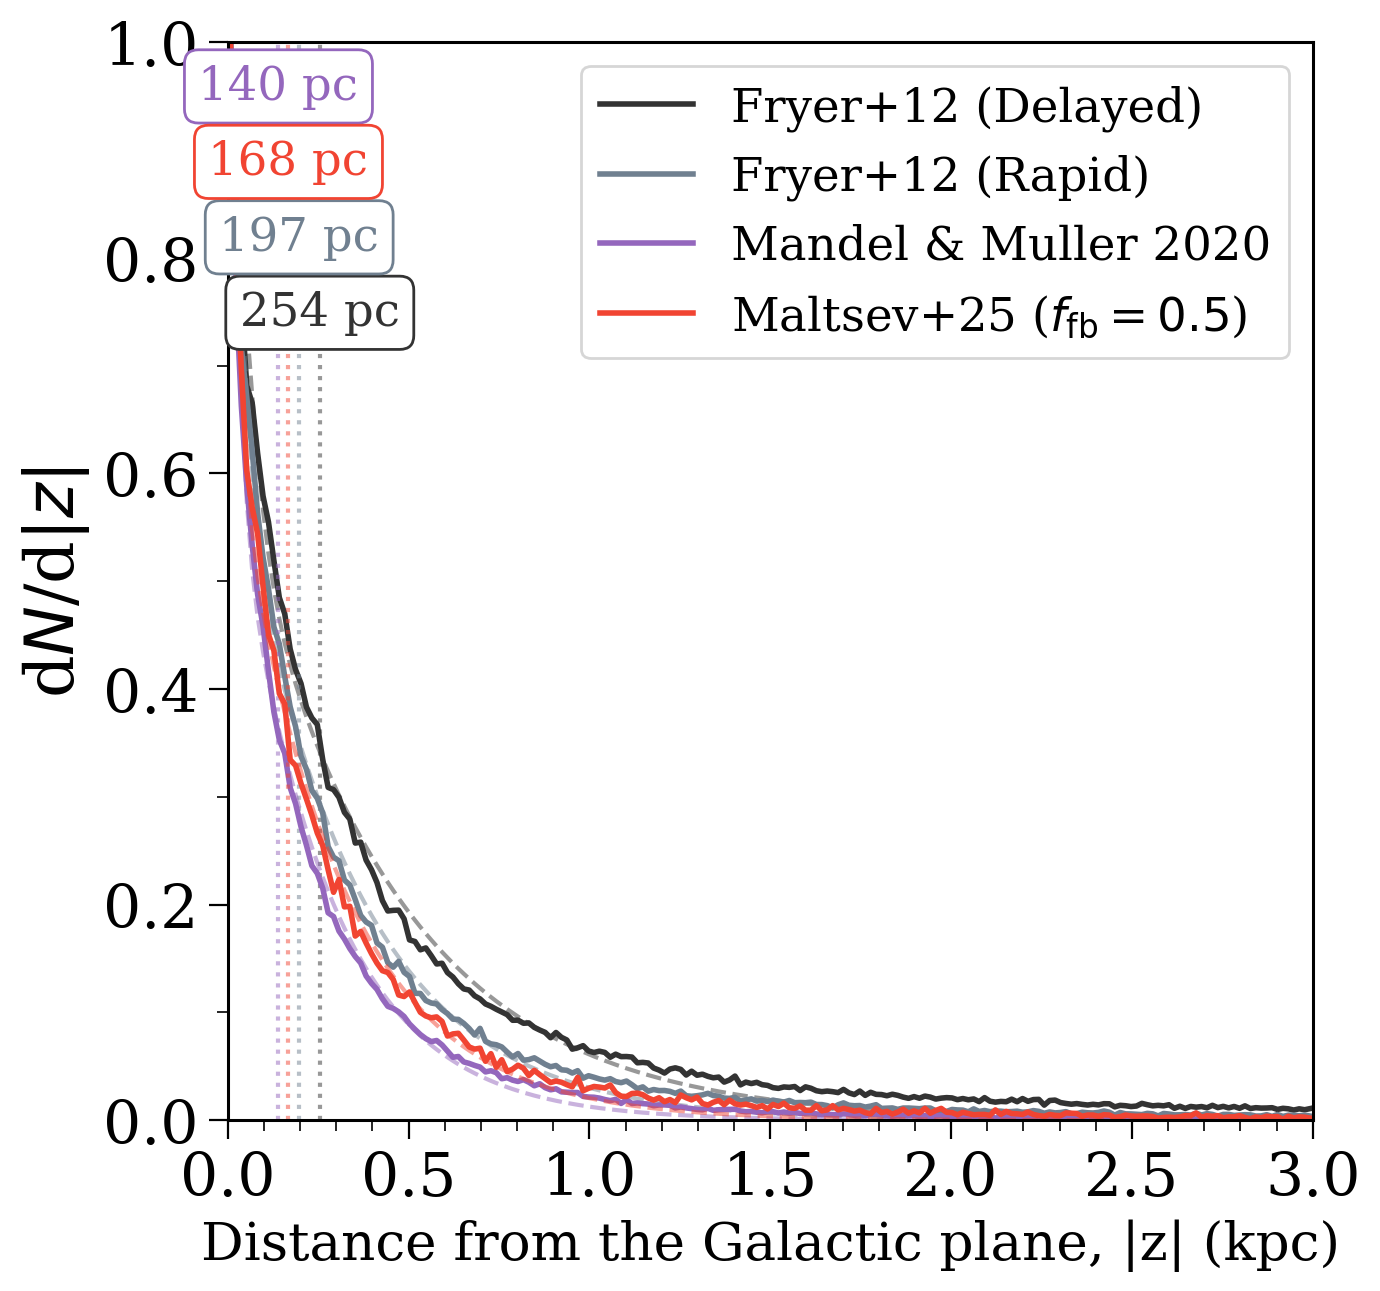

In [ ]:
reload(plotting)
fig, ax = plt.subplots(figsize=(7, 7))

for pop, loc in zip([pops[0], pops[1], pops[2], pops[5]], [0.98 - 0.07 * 3, 0.98 - 0.07 * 2, 0.98 - 0.07 * 0, 0.98 - 0.07 * 1]):
    plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc
    )


ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

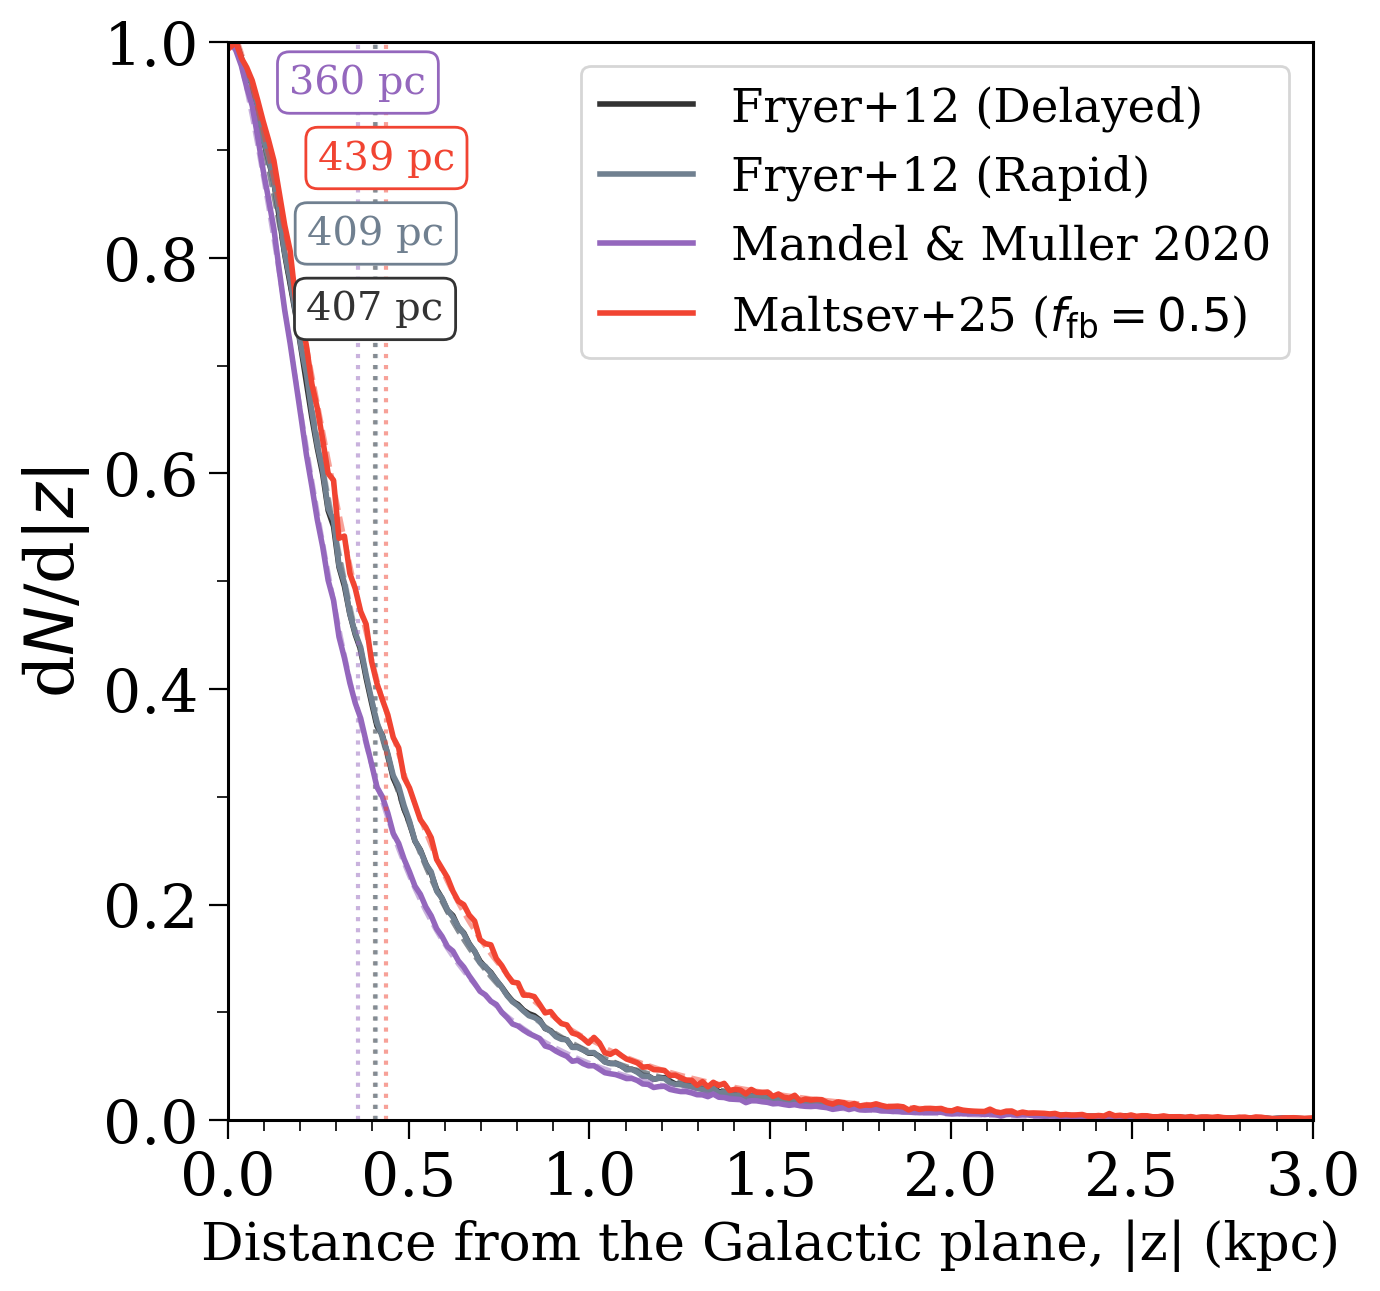

In [20]:
reload(plotting)
fig, ax = plt.subplots(figsize=(7, 7))

for pop, loc in zip([pops[0], pops[1], pops[2], pops[5]], [0.98 - 0.07 * 3, 0.98 - 0.07 * 2, 0.98 - 0.07 * 0, 0.98 - 0.07 * 1]):
    plotting.estimate_scale_height(
        z=data[pop.label]["init_z"]["BH"][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc
    )


ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [10]:
n_bhs = []

for i, pop in enumerate(pops):
    scale_up = 6e10 / data[pop.label]["mass_binaries"]
    n_ns = len(data[pop.label]["bin_nums"]["NS"])
    n_bh = len(data[pop.label]["bin_nums"]["BH"])
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
    print(f"  Scaled totals: {(n_ns + n_bh) * scale_up:1.1e}, NSs: {n_ns * scale_up:1.1e}, BHs: {n_bh * scale_up:1.1e}")
    n_bhs.append(n_bh * scale_up)

Fryer+12 (Delayed)
  Total: 1007052, NSs: 757585, BHs: 249467
  Scaled totals: 6.6e+08, NSs: 5.0e+08, BHs: 1.6e+08
Fryer+12 (Rapid)
  Total: 1005524, NSs: 812868, BHs: 192656
  Scaled totals: 6.6e+08, NSs: 5.3e+08, BHs: 1.3e+08
Mandel & Muller 2020
  Total: 992085, NSs: 668632, BHs: 323453
  Scaled totals: 6.5e+08, NSs: 4.4e+08, BHs: 2.1e+08
Maltsev+25 ($f_{\rm fb}=0.0$)
  Total: 1012673, NSs: 969341, BHs: 43332
  Scaled totals: 6.6e+08, NSs: 6.3e+08, BHs: 2.8e+07
Maltsev+25 ($f_{\rm fb}=0.25$)
  Total: 1012412, NSs: 960094, BHs: 52318
  Scaled totals: 6.6e+08, NSs: 6.3e+08, BHs: 3.4e+07
Maltsev+25 ($f_{\rm fb}=0.5$)
  Total: 1012357, NSs: 958989, BHs: 53368
  Scaled totals: 6.6e+08, NSs: 6.3e+08, BHs: 3.5e+07
Maltsev+25 ($f_{\rm fb}=0.75$)
  Total: 1012105, NSs: 958704, BHs: 53401
  Scaled totals: 6.6e+08, NSs: 6.3e+08, BHs: 3.5e+07
Maltsev+25 ($f_{\rm fb}=1.0$)
  Total: 1012643, NSs: 959349, BHs: 53294
  Scaled totals: 6.6e+08, NSs: 6.3e+08, BHs: 3.5e+07
Maltsev+25 ($P({\rm pf})=0.0$

/tmp/ipykernel_438890/1892890701.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace(" (", "\n(").replace("& ", "&\n") for l in labels], rotation=0, ha="center", fontsize=0.4*fs)


Text(5, 120000000.0, 'Olejak+20')

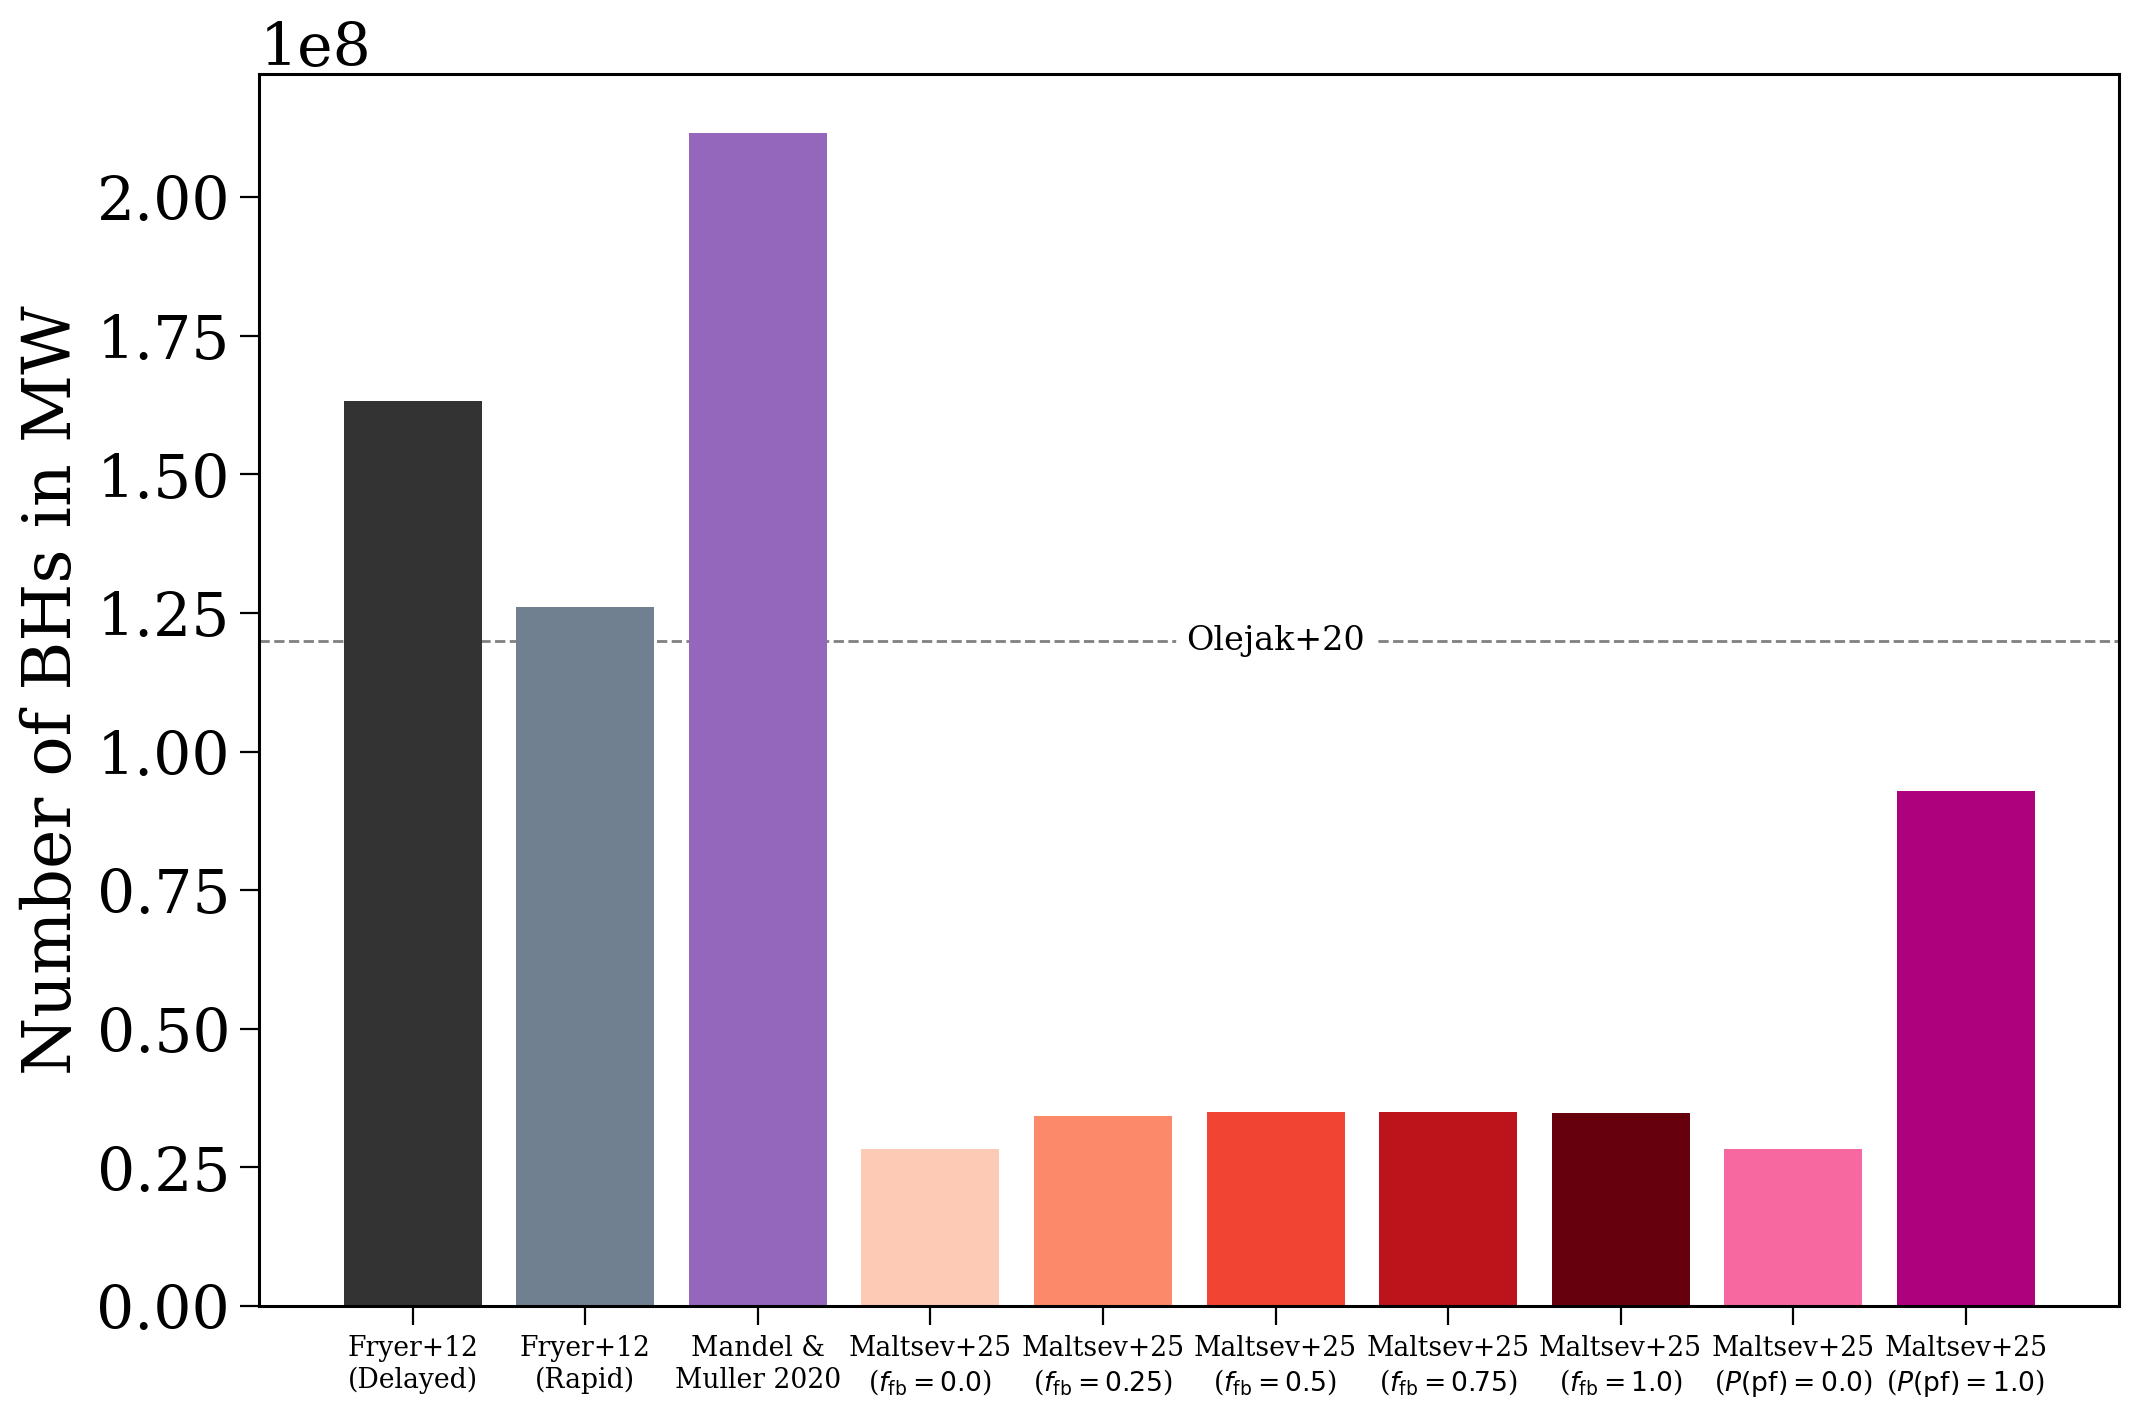

In [11]:
fig, ax = plt.subplots()

ax.bar(labels, n_bhs, color=colours)
ax.set_ylabel("Number of BHs in MW")

ax.set_xticklabels([l.replace(" (", "\n(").replace("& ", "&\n") for l in labels], rotation=0, ha="center", fontsize=0.4*fs)

ax.axhline(1.2e8, color='grey', linestyle='--', linewidth=1, zorder=-1)
ax.annotate("Olejak+20", xy=(5, 1.2e8), ha='center', va='center', fontsize=0.5*fs, bbox=dict(boxstyle="round", fc="white", ec="none"))

Inner 10 kpc
  Fryer+12 (Delayed) fraction within 0.5 kpc 0.52
  Fryer+12 (Rapid) fraction within 0.5 kpc 0.63
  Mandel & Muller 2020 fraction within 0.5 kpc 0.74
  Maltsev+25 ($f_{\rm fb}=0.0$) fraction within 0.5 kpc 0.75
  Maltsev+25 ($f_{\rm fb}=0.25$) fraction within 0.5 kpc 0.69
  Maltsev+25 ($f_{\rm fb}=0.5$) fraction within 0.5 kpc 0.68
  Maltsev+25 ($f_{\rm fb}=0.75$) fraction within 0.5 kpc 0.69
  Maltsev+25 ($f_{\rm fb}=1.0$) fraction within 0.5 kpc 0.74
  Maltsev+25 ($P({\rm pf})=0.0$) fraction within 0.5 kpc 0.75
  Maltsev+25 ($P({\rm pf})=1.0$) fraction within 0.5 kpc 0.49
Full population
  Fryer+12 (Delayed) fraction within 0.5 kpc 0.48
  Fryer+12 (Rapid) fraction within 0.5 kpc 0.61
  Mandel & Muller 2020 fraction within 0.5 kpc 0.74
  Maltsev+25 ($f_{\rm fb}=0.0$) fraction within 0.5 kpc 0.75
  Maltsev+25 ($f_{\rm fb}=0.25$) fraction within 0.5 kpc 0.66
  Maltsev+25 ($f_{\rm fb}=0.5$) fraction within 0.5 kpc 0.66
  Maltsev+25 ($f_{\rm fb}=0.75$) fraction within 0.5 kpc

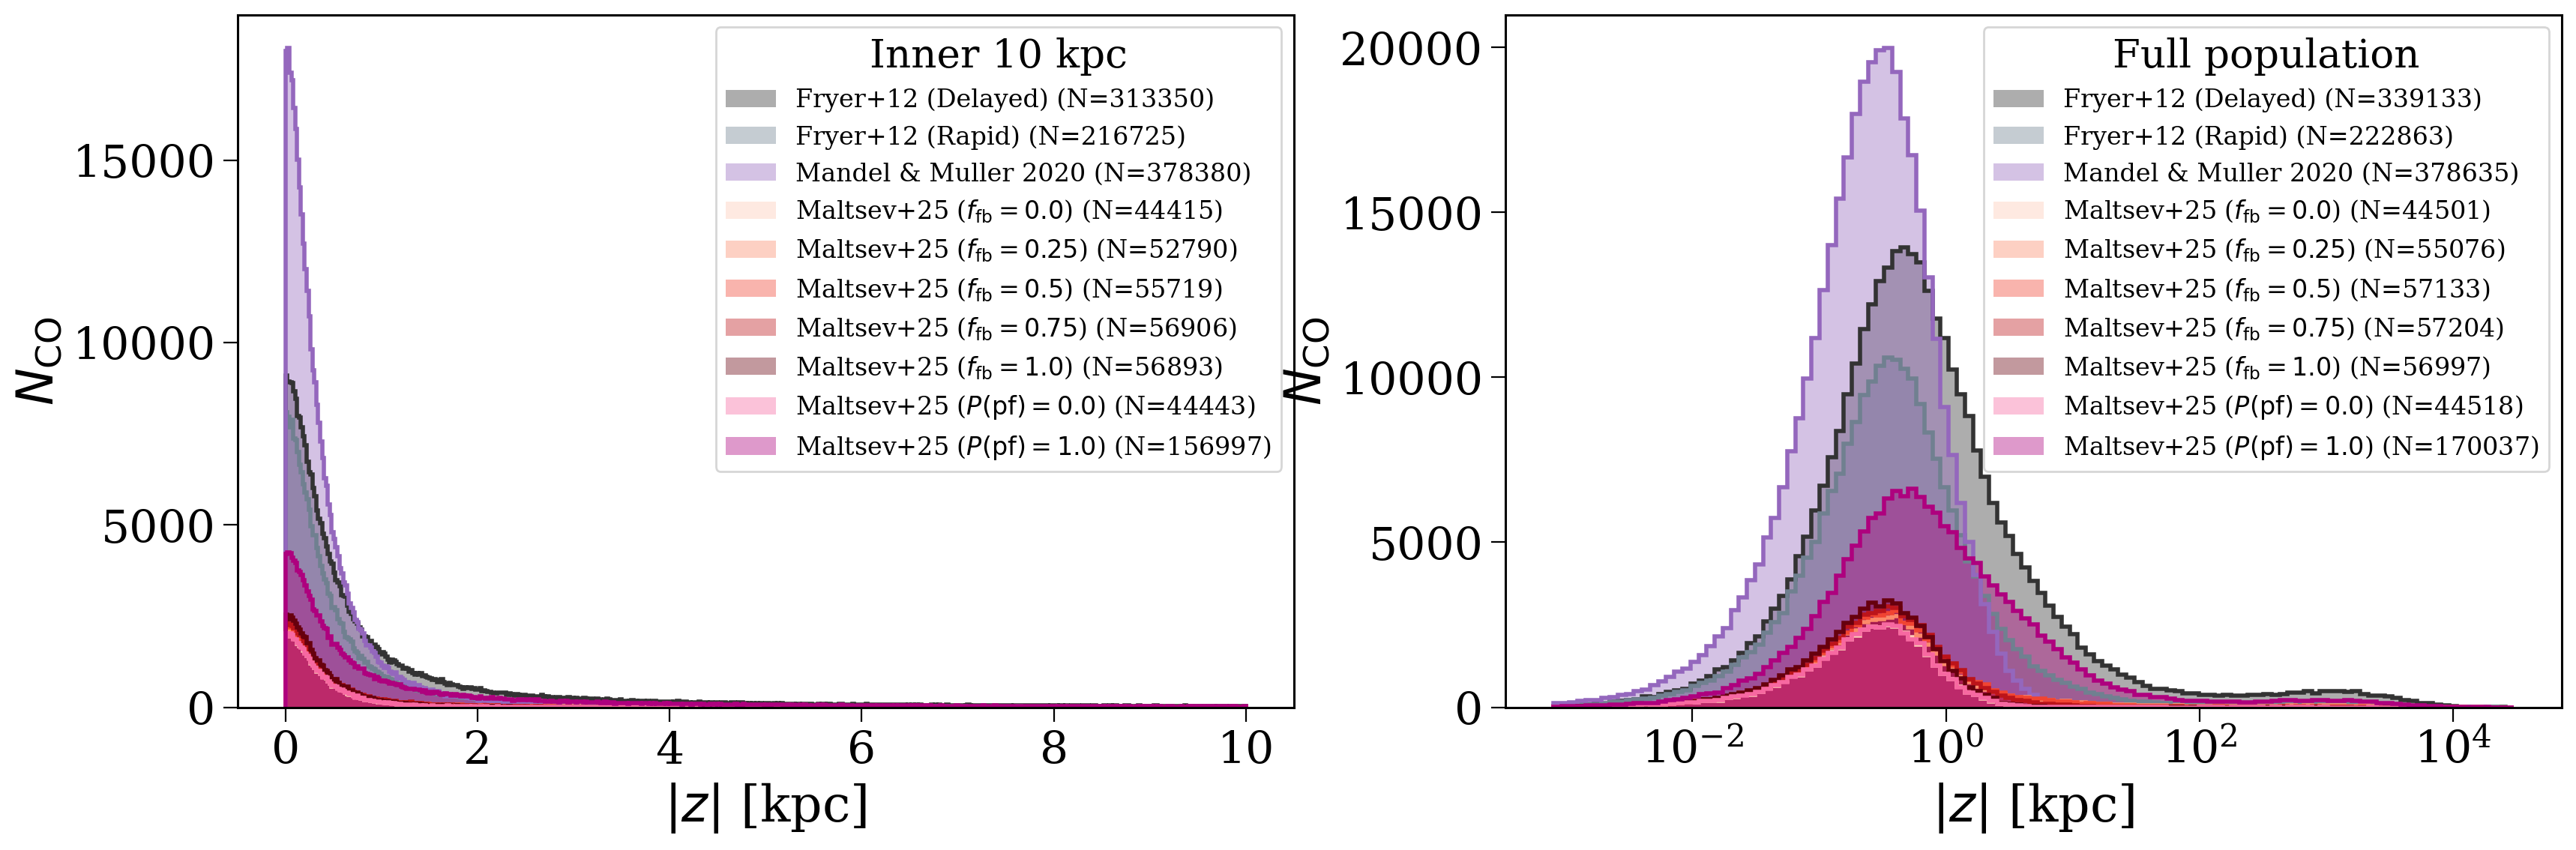

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [28]:
plotting.absolute_galactocentric_height(pops, data, co_type="BH")

In [16]:
print("Escaped fractions:")
for pop in pops:
    escaped = data[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {data[pop.label]["escaped"]["CO"].sum() / len(data[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {data[pop.label]["escaped"]["BH"].sum() / len(data[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {data[pop.label]["escaped"]["NS"].sum() / len(data[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Fryer+12 (Delayed):
      - CO = 0.105
      - BH = 0.029
      - NS = 0.134
  - Fryer+12 (Rapid):
      - CO = 0.112
      - BH = 0.009
      - NS = 0.137
  - Mandel & Muller 2020:
      - CO = 0.106
      - BH = 0.000
      - NS = 0.157
  - Maltsev+25 ($f_{\rm fb}=0.0$):
      - CO = 0.135
      - BH = 0.000
      - NS = 0.140
  - Maltsev+25 ($f_{\rm fb}=0.25$):
      - CO = 0.134
      - BH = 0.017
      - NS = 0.139
  - Maltsev+25 ($f_{\rm fb}=0.5$):
      - CO = 0.133
      - BH = 0.007
      - NS = 0.140
  - Maltsev+25 ($f_{\rm fb}=0.75$):
      - CO = 0.133
      - BH = 0.001
      - NS = 0.140
  - Maltsev+25 ($f_{\rm fb}=1.0$):
      - CO = 0.133
      - BH = 0.000
      - NS = 0.140
  - Maltsev+25 ($P({\rm pf})=0.0$):
      - CO = 0.135
      - BH = 0.000
      - NS = 0.140
  - Maltsev+25 ($P({\rm pf})=1.0$):
      - CO = 0.121
      - BH = 0.023
      - NS = 0.137


In [12]:
z_range = np.geomspace(0.1, 10, 1000)

abs_zs = [np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops]

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=abs_zs + [np.abs(data["Fryer+12 (Delayed)"]["init_z"]["BH"])],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data["Fryer+12 (Delayed)"]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

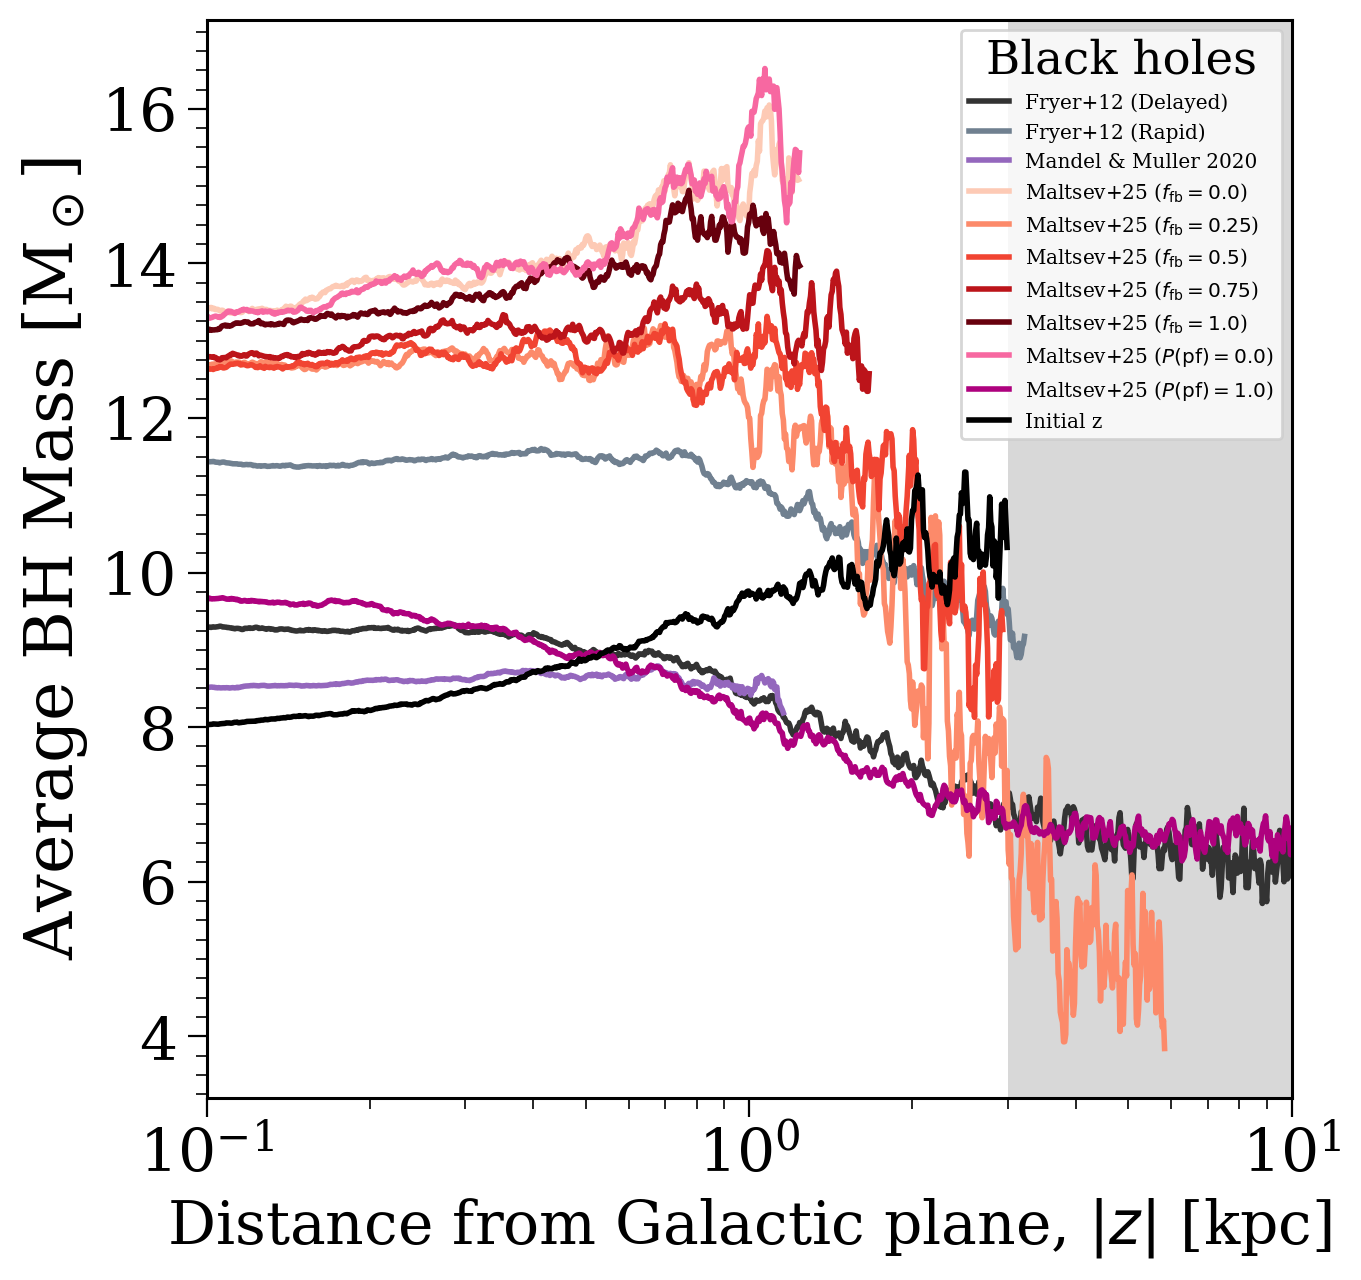

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [13]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses, labels=[pop.label for pop in pops] + ["Initial z"], colours=[pop.colour for pop in pops] + ["k"],
    z_maxes=[np.percentile(abs_zs[i], 95) for i in range(len(pops))] + [3], z_range=z_range,
    legend_kwargs={
        "fontsize": 0.3 * fs
    }
)